# Notebook 3 : Transformation de Perspective et Homographie

## Objectif
Ce notebook traite de la projection géométrique. La caméra de télévision filmant avec un angle et une perspective (trapézoïdale), il est nécessaire de transformer les coordonnées des joueurs détectés pour les placer sur une représentation 2D du terrain vue de dessus (orthogonale).

## 1. Définition des points
Nous devons mapper 4 points de l'écran (pixels) vers 4 points du terrain 2D (mètres).
Pour cet exemple, nous allons simuler les points sources.

1. Coin Haut-Gauche de la surface
2. Coin Bas-Gauche de la surface
3. Coin Bas-Droit de la surface
4. Coin Haut-Droit de la surface

Calcul de src_points

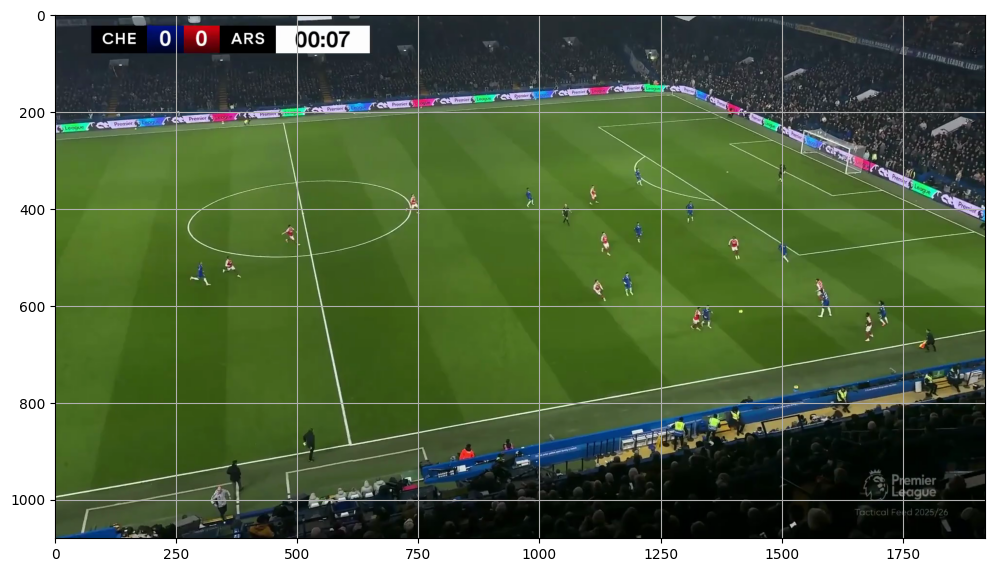

In [1]:
import matplotlib.pyplot as plt
import cv2
cap = cv2.VideoCapture('input_video.mp4')
ret, frame = cap.read()
cap.release()
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8))
plt.imshow(frame_rgb)
plt.grid(True) # Grille importante pour mieux voir les pixels
plt.show()

In [3]:
import numpy as np

src_points = np.array([
    [1585, 245],   # Point 1 : Coin des 16m (au fond / loin)
    [1690, 815],   # Point 2 : Coin des 16m (devant / proche)
    [1910, 750],   # Point 3 : Coin ligne de but (devant / proche)
    [1775, 205]    # Point 4 : Coin ligne de but (au fond / loin)
], dtype=np.float32)

# Coordonnées réelles sur un terrain standard (en mètres)
# Supposons que nous avons mappé la surface de réparation (16.5m x 40.3m)
dst_points = np.array([
    [88.5, 13.84], # Point 1 : X=88.5m, Y est centré (68 - 40.3)/2
    [88.5, 54.16], # Point 2 : X=88.5m, Y bas
    [105,  54.16], # Point 3 : X=105m,  Y bas (Ligne de but)
    [105,  13.84]  # Point 4 : X=105m,  Y haut (Ligne de but)
], dtype=np.float32)

Pour faire simple, ces points sont des paires de coordonnées qui relient l'image de la télévision (déformée par la perspective) à la réalité du terrain (plat).

Les dimensions 16.5 et 40.3 correspondent à la Surface de Réparation (qui fait officiellement 16,5m de profondeur sur 40,32m de largeur).

1. Ce que voit la caméra (src_points en Pixels)
C'est une forme de Trapèze. À cause de l'angle de la caméra, le fond est plus petit que le devant.

Point 1 : Coin Haut-Gauche de la surface (sur l'écran).

Point 4 : Coin Haut-Droit de la surface (sur l'écran).

Point 2 : Coin Bas-Gauche de la surface (sur l'écran).

Point 3 : Coin Bas-Droit de la surface (sur l'écran).

2. La réalité  (dst_points en Mètres)
C'est un Rectangle parfait.

Point 1 [0, 0] : Le point de départ (Ligne de but / Ligne de touche ou Poteau de corner).

Point 4 [16.5, 0] : On avance de 16,5m vers le centre du terrain (la ligne des 16mètres).

Point 2 [0, 40.3] : On descend de 40,3m le long de la ligne de but.

Point 3 [16.5, 40.3] : L'intersection finale qui ferme le rectangle.

En résumé
L'ordinateur va calculer comment "tirer" sur les coins du trapèze (Image 1) pour qu'ils deviennent les coins du rectangle (Image 2). Une fois qu'il a compris cette déformation pour ces 4 points, il peut l'appliquer à tous les joueurs pour trouver leur vraie position.

## 2. Calcul de la Matrice d'Homographie
OpenCV calcule la matrice magique qui permet de passer de `src` à `dst`.

In [4]:
homography_matrix, status = cv2.findHomography(src_points, dst_points)

print("Matrice d'Homographie calculée :")
print(homography_matrix)

Matrice d'Homographie calculée :
[[ 7.26506020e-02  1.38413022e-02 -3.28302648e+01]
 [ 1.54375879e-02  8.23253728e-02 -3.12342829e+01]
 [-6.94013147e-05  3.20403750e-04  1.00000000e+00]]


## 3. Fonction de transformation
Cette fonction prend un point (x, y) de la vidéo et retourne sa position (x, y) sur le terrain 2D.

In [5]:
def transform_point(x, y, matrix):
    # Format requis par OpenCV: shape (1, 1, 2)
    pts = np.array([[[x, y]]], dtype=np.float32)
    transformed = cv2.perspectiveTransform(pts, matrix)
    return transformed[0][0]

# Test
video_x, video_y = 500, 400
pitch_x, pitch_y = transform_point(video_x, video_y, homography_matrix)
print(f"Le pixel ({video_x}, {video_y}) correspond à la position ({pitch_x:.2f}m, {pitch_y:.2f}m) sur le terrain.")

Le pixel (500, 400) correspond à la position (8.26m, 8.61m) sur le terrain.


## 4. Visualisation du terrain vide

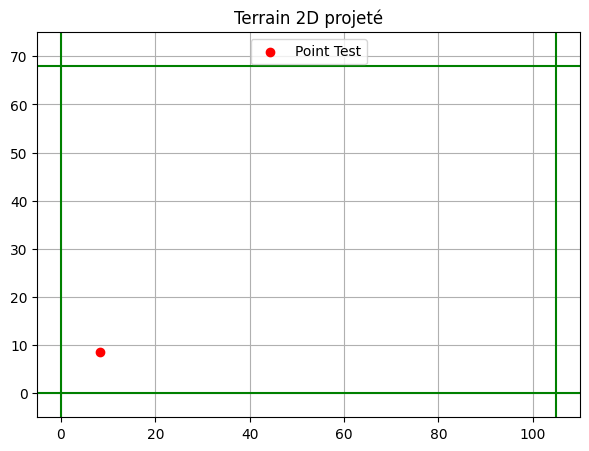

In [6]:
def draw_pitch():
    plt.figure(figsize=(7, 5))
    plt.xlim(-5, 110) # Terrain standard env. 105m
    plt.ylim(-5, 75)  # Largeur env. 68m
    plt.axvline(x=0, color='green') # Ligne de but
    plt.axvline(x=105, color='green')
    plt.axhline(y=0, color='green')
    plt.axhline(y=68, color='green')
    plt.title("Terrain 2D projeté")
    plt.grid(True)

draw_pitch()
# On affiche le point test
plt.scatter(pitch_x, pitch_y, c='red', label='Point Test')
plt.legend()
plt.show()

### Résultat pas très cohérent du au fait que la caméra n'est pas fixe (impossible d'étendre la perspective)

Par la suite, pour une meilleure étude, il aurait fallu sans doute également utiliser des coordonnées plus précises (en début du notebook avec la grille)